# Labor Force Survey - Exploratory Data Analysis (EDA)

Created by JF Viray

This notebook is for the exploratory data analysis from the [Labor Force Survey (LFS) of April 2025](https://psada.psa.gov.ph/catalog/LFS/about). Specifically, we wish to find:
1. Find the difference in the between the youth labor force and the overall labor force
2. Composition of the Labor Force by Education Pathways
3. For each education pathway, find:
    * Unemployment
    * Employment
    * Self-Employment
    * Underemployment
    * TESDA

Below are the relevant fields from the LFS. I have also included below the description, purpose, and the codes.
| Column Name        | Description                                      | Purpose |
|--------------------|--------------------------------------------------|----------|
| PUFPWGTPRV         | Final Weight Based on Projection                | To get the estimated number (weighted estimate) of each sample |
| PUFC05_AGE          | Age as of Last Birthday                         | To get the age of the participant|
| PUFNEWEMPSTAT      | New Employment Criteria (Jul 05, 2005)          | To determine employment status |
| PUFC20_PWMORE      | Want More Hours of Work                         | To determine if underemployed |
| PUFC23_PCLASS      | Class of Worker (Primary Occupation)            | To classify worker type |
| PUFC07_GRADE       | Highest Grade Completed                         | To determine schooling level |
| PUFC09_GRADTECH    | Graduate of technical/vocational course         | To determine if TESDA graduate or not |
| PUFC25_PBASIC      | Basic Pay per Day from the Primary Occupation   | To determine the wage |
1. PUFNEWEMPSTAT — Employment Status

| Code | Description            |
| ---- | ---------------------- |
| 1    | Employed               |
| 2    | Unemployed             |
| 3    | Not in the Labor Force |

2. PUFC05_AGE - Age as of Last Birthday
This is in integer 

3. PUFC20_PWMORE — Want More Hours of Work

| Code | Description |
| ---- | ----------- |
| 1    | Yes         |
| 2    | No          |

4. PUFC23_PCLASS — Class of Worker (Primary Occupation)

| Code | Description                         |
| ---- | ----------------------------------- |
| 0    | Private Household                   |
| 1    | Private Establishment               |
| 2    | Government / Government Corporation |
| 3    | Self Employed                       |
| 4    | Employer                            |
| 5    | With Pay (Family-owned Business)    |
| 6    | Without Pay (Family-owned Business) |

5. PUFC09_GRADTECH — Graduate of Technical/Vocational Course

Code	Description
| Code | Description |
| ---- | ----------- |
| 1    | Yes         |
| 2    | No          |

6. PUFC07_GRADE — Highest Grade Completed

| Code Range    | Description                      |
| ------------- | -------------------------------- |
| 0 – 2000      | No Grade Completed               |
| 10004 – 10015 | Elementary Undergraduate         |
| 10018         | Elementary Graduate              |
| 24004 – 24013 | Junior High School Undergraduate |
| 24014 – 24015 | Junior High School Completed     |
| 34011 – 35011 | Senior High School Undergraduate |
| 34013 – 35013 | Senior High School Graduate      |
| 40001 – 50003 | Post Secondary Undergraduate     |
| 40011 – 59999 | Post Secondary Graduate          |
| 60001 – 60006 | College Undergraduate            |
| 60000 – 89999 | College Graduate                 |

7. PUFC25_PBASIC - Basic Pay per Day (Primary Occupation)
This is already in integers. 

# I. Cleaning the Data

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set the font
from matplotlib import font_manager as fm
fpath = "Microsoft Aptos Fonts/Aptos.ttf"
prop = fm.FontProperties(fname=fpath)
#plt.rcParams['font.family'] = 'Aptos'

from matplotlib.ticker import FuncFormatter

In [ ]:
# Open and combine the January and April files
relevant_cols = ['PUFPWGTPRV', # Final Weight Based on Projection
                 'PUFC05_AGE', # Age
                 'PUFNEWEMPSTAT', # Employed (1), Unemployed (2), Not in the Labor Force (3)
                 'PUFC20_PWMORE', # Underemployed (1), NOT underemployed (2)
                 'PUFC23_PCLASS', # Self-Employed (3)
                 'PUFC07_GRADE', # Look at the code
                 'PUFC09_GRADTECH', # Went through TESDA (1), Did NOT go through TESDA (2)
                 'PUFC25_PBASIC' # Pay per Day
]

filepath = 'data/PHL-PSA-LFS-2025-01-PUF/LFS PUF January 2025.CSV'
jan_df = pd.read_csv(filepath)

filepath = 'data/PHL-PSA-LFS-2025-04-PUF/LFS PUF April 2025.CSV'
apr_df = pd.read_csv(filepath)
apr_df = apr_df[relevant_cols].replace(' ', np.nan)
apr_df = apr_df[relevant_cols].replace('     ', np.nan)
#apr_df.dropna(inplace=True)

# combined_df = pd.concat([jan_df, apr_df])
# combined_df = combined_df[relevant_cols].replace(' ', np.nan)

In [20]:
is_lf = (apr_df['PUFNEWEMPSTAT'] == '1') | (apr_df['PUFNEWEMPSTAT'] == '2') 
is_youth = apr_df['PUFC05_AGE'] <= 24
lf_df = apr_df[is_lf & is_youth].copy()

We convert the code in the PUFC07_GRADE to something actually understandable.

In [21]:
# Education code ranges
education_ranges = {
    "No grade completed": [(0, 1000), (2000, 2000)],
    "Elementary Undergraduate": [(10011, 10015), (10004, 10006)],
    "Elementary Graduate": [(10018, 10018)],
    "Junior High School Undergraduate": [(24011, 24013), (24004, 24006)],
    "Junior High School Graduate": [(24014, 24015)],
    "Senior High School Undergraduate": [(34011, 34011), (34021, 34021), (34031, 34031), (35011, 35011)],
    "Senior High School Graduate": [(34013, 34013), (34023, 34023), (34033, 34033), (35013, 35013)],
    "Post Secondary Undergraduate": [(40001, 40003), (50001, 50003)],
    "Post Secondary Graduate": [(40011, 49999), (50011, 59999)],
    "College Undergraduate": [(60001, 60006)],
    "College Graduate": [(60000, 60000), (60011, 69999), (70000, 79999), (80000, 89999)]
}

def classify_education(code):
    """Classify the code to what grade it was completed"""
    for level, ranges in education_ranges.items():
        for lower, upper in ranges:
            if lower <= code <= upper:
                return level
    return "Unknown"

# Mapping to simplified education levels: Undergraduate vs Graduate
grade_map = {
    "Junior High School Graduate": "Junior High School",
    "College Graduate": "Higher Education Institution",
    "Elementary Graduate":"Elementary",
    "Elementary Undergraduate":"No grade completed",
    "Junior High School Undergraduate":"Elementary",
    "College Undergraduate":"Senior High School",
    "Post Secondary Graduate":"Higher Education Institution",
    "Senior High School Graduate":"Senior High School",
    "No grade completed": "No grade completed",
    "Senior High School Undergraduate": "Junior High School",
    "Post Secondary Undergraduate":"Senior High School"
}

# Finally get the grade
lf_df.loc[:, 'Grade'] = lf_df['PUFC07_GRADE'].astype(int).map(classify_education).map(grade_map)


# II. Composition of the Labor Force by Education Pathways

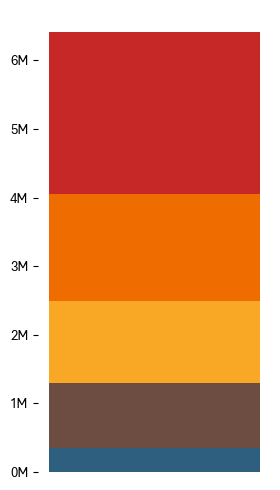

In [22]:
lf_education = lf_df.groupby('Grade')['PUFPWGTPRV'].sum().sort_values()

colors = [
    "#C62828",  # deep red
    "#EF6C00",  # orange
    "#F9A825",  # golden
    "#6D4C41",  # brown
    "#2E5F7F"   # muted blue-gray
]

fig, ax = plt.subplots(figsize=(3, 6))
bottom = 0
for (category, value), color in zip(lf_education.items(), colors[::-1]):
    plt.bar("Young Workforce", value, bottom=bottom, color=color)
    bottom += value

# Remove the spines
for spine in ['top', 'right', 'bottom', 'left']:
    plt.gca().spines[spine].set_visible(False)

# Clean the x and y axis
for tick in ax.get_yticklabels():
    tick.set_fontproperties(prop)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x/1e6)}M'))

ax.set_xticks([])

plt.show()

In [23]:
lf_education

Grade
No grade completed              3.506747e+05
Higher Education Institution    9.447753e+05
Elementary                      1.198692e+06
Junior High School              1.555919e+06
Senior High School              2.365317e+06
Name: PUFPWGTPRV, dtype: float64

In [24]:
lf_education / lf_education.sum()

Grade
No grade completed              0.054662
Higher Education Institution    0.147267
Elementary                      0.186847
Junior High School              0.242530
Senior High School              0.368695
Name: PUFPWGTPRV, dtype: float64

# II. Unemployment, Employment, Self-Employment, Underemployment, TESDA Rate, and Pay of the Labor Force by Education Pathways

In [25]:
# Unemployment AND Employment
employment_grouped = lf_df.groupby(['Grade', 'PUFNEWEMPSTAT'])['PUFPWGTPRV'].sum()


# Normalize per grade
employment_grouped_percent = employment_grouped.reset_index()
employment_grouped_percent.loc[:, 'Total'] = employment_grouped_percent.groupby('Grade')['PUFPWGTPRV'].transform('sum')
employment_grouped_percent.loc[:, 'Percent'] = employment_grouped_percent['PUFPWGTPRV'] / employment_grouped_percent['Total']
employment_grouped_percent

,Grade,PUFNEWEMPSTAT,PUFPWGTPRV,Total,Percent
0,Elementary,1,1.110520e+06,1.198692e+06,0.926443
1,Elementary,2,8.817224e+04,1.198692e+06,0.073557
2,Higher Education Institution,1,7.488466e+05,9.447753e+05,0.792619
3,Higher Education Institution,2,1.959288e+05,9.447753e+05,0.207381
4,Junior High School,1,1.431295e+06,1.555919e+06,0.919903
5,Junior High School,2,1.246238e+05,1.555919e+06,0.080097
6,No grade completed,1,3.348573e+05,3.506747e+05,0.954894
7,No grade completed,2,1.581741e+04,3.506747e+05,0.045106
8,Senior High School,1,2.051690e+06,2.365317e+06,0.867406
9,Senior High School,2,3.136269e+05,2.365317e+06,0.132594


In [ ]:
lf_df.dropna(subset=['PUFC25_PBASIC'])
lf_df.groupby(['Grade', 'PUFNEWEMPSTAT'])['PUFC25_PBASIC'].sum()

Grade                         PUFNEWEMPSTAT
Elementary                    1                0058000450003000050000350003000025000500003500...
                              2                                                                0
Higher Education Institution  1                0056800450005000045000400004000040000580005000...
                              2                                                                0
Junior High School            1                0060000300004000050000200002000050000250002000...
                              2                                                                0
No grade completed            1                0045000450004000040000500008000050000192005000...
                              2                                                                0
Senior High School            1                0040000400004500046800493004000050000450002000...
                              2                                                    

In [ ]:
payed_lf_df = lf_df.dropna(subset=['PUFC25_PBASIC']).copy()
payed_lf_df.loc[:, 'Wage'] = payed_lf_df['PUFC25_PBASIC'].astype(int)
payed_lf_df.groupby('Grade')['Wage'].mean()

Grade
Elementary                      377.546061
Higher Education Institution    666.492276
Junior High School              422.251779
No grade completed              360.806034
Senior High School              470.827513
Name: Wage, dtype: float64

In [43]:
payed_lf_df = lf_df.dropna(subset=['PUFC25_PBASIC']).copy()
payed_lf_df.loc[:, 'Wage'] = payed_lf_df['PUFC25_PBASIC'].astype(int)
payed_lf_df.groupby('Grade')['Wage'].median()

Grade
Elementary                      400.0
Higher Education Institution    600.0
Junior High School              400.0
No grade completed              350.0
Senior High School              450.0
Name: Wage, dtype: float64